# Load duration curves and harmonics of the retained models

Two shape criteria of the validation contract, shown target by target:

- **load duration curve**: the mean daily profile sorted by decreasing power, so that the time of
  day disappears and only the distribution of power remains;
- **harmonics**: amplitudes of the first ten daily harmonics of the mean profile,
  2 |FFT| / 96, which describe how the load is shared between slow and fast variations.

Measured profile in grey, RAMP model in blue. The gap printed on each panel is the criterion of
the validation contract (`LDC_err`, `FFT_err`). The figures come from `src/step10_ldc_fft.py`,
which reads the committed results only.

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

REPO = Path.cwd().resolve().parents[1]      # repository root, two levels above notebooks/curves/
CURVES = REPO / "resultats" / "courbes"
SEASONS = REPO / "resultats" / "reference_saison" / "publication" / "tableaux" / "bilan_complet.csv"
MONTHS = REPO / "resultats" / "calib_mois" / "publication" / "tableaux" / "bilan_complet.csv"


def spread(table, key):
    """Mean, median, maximum and number of targets above 10 % for one criterion, in percent."""
    x = 100 * table[key]
    return {"mean": round(x.mean(), 1), "median": round(x.median(), 1), "max": round(x.max(), 1),
            "above 10 %": f"{(x > 10).sum()} / {len(x)}"}


# Both criteria, seasonal and monthly grain
rows = {}
for grain, path in (("seasons", SEASONS), ("months", MONTHS)):
    table = pd.read_csv(path)
    for key in ("LDC_err", "FFT_err"):
        rows[f"{key}, {grain}"] = spread(table, key)
pd.DataFrame(rows).T

,mean,median,max,above 10 %
"LDC_err, seasons",4.7,4.9,7.8,0 / 36
"FFT_err, seasons",16.7,15.1,34.6,32 / 36
"LDC_err, months",5.2,4.9,9.8,0 / 98
"FFT_err, months",19.4,18.5,81.8,83 / 98


The load duration curve stays under 10 % on every target, seasonal and monthly: the models
spend the right amount of time at each power level. The harmonics are the weak criterion, above
10 % on 32 of the 36 seasonal targets and 83 of the 98 monthly ones.

## Seasonal targets (36)

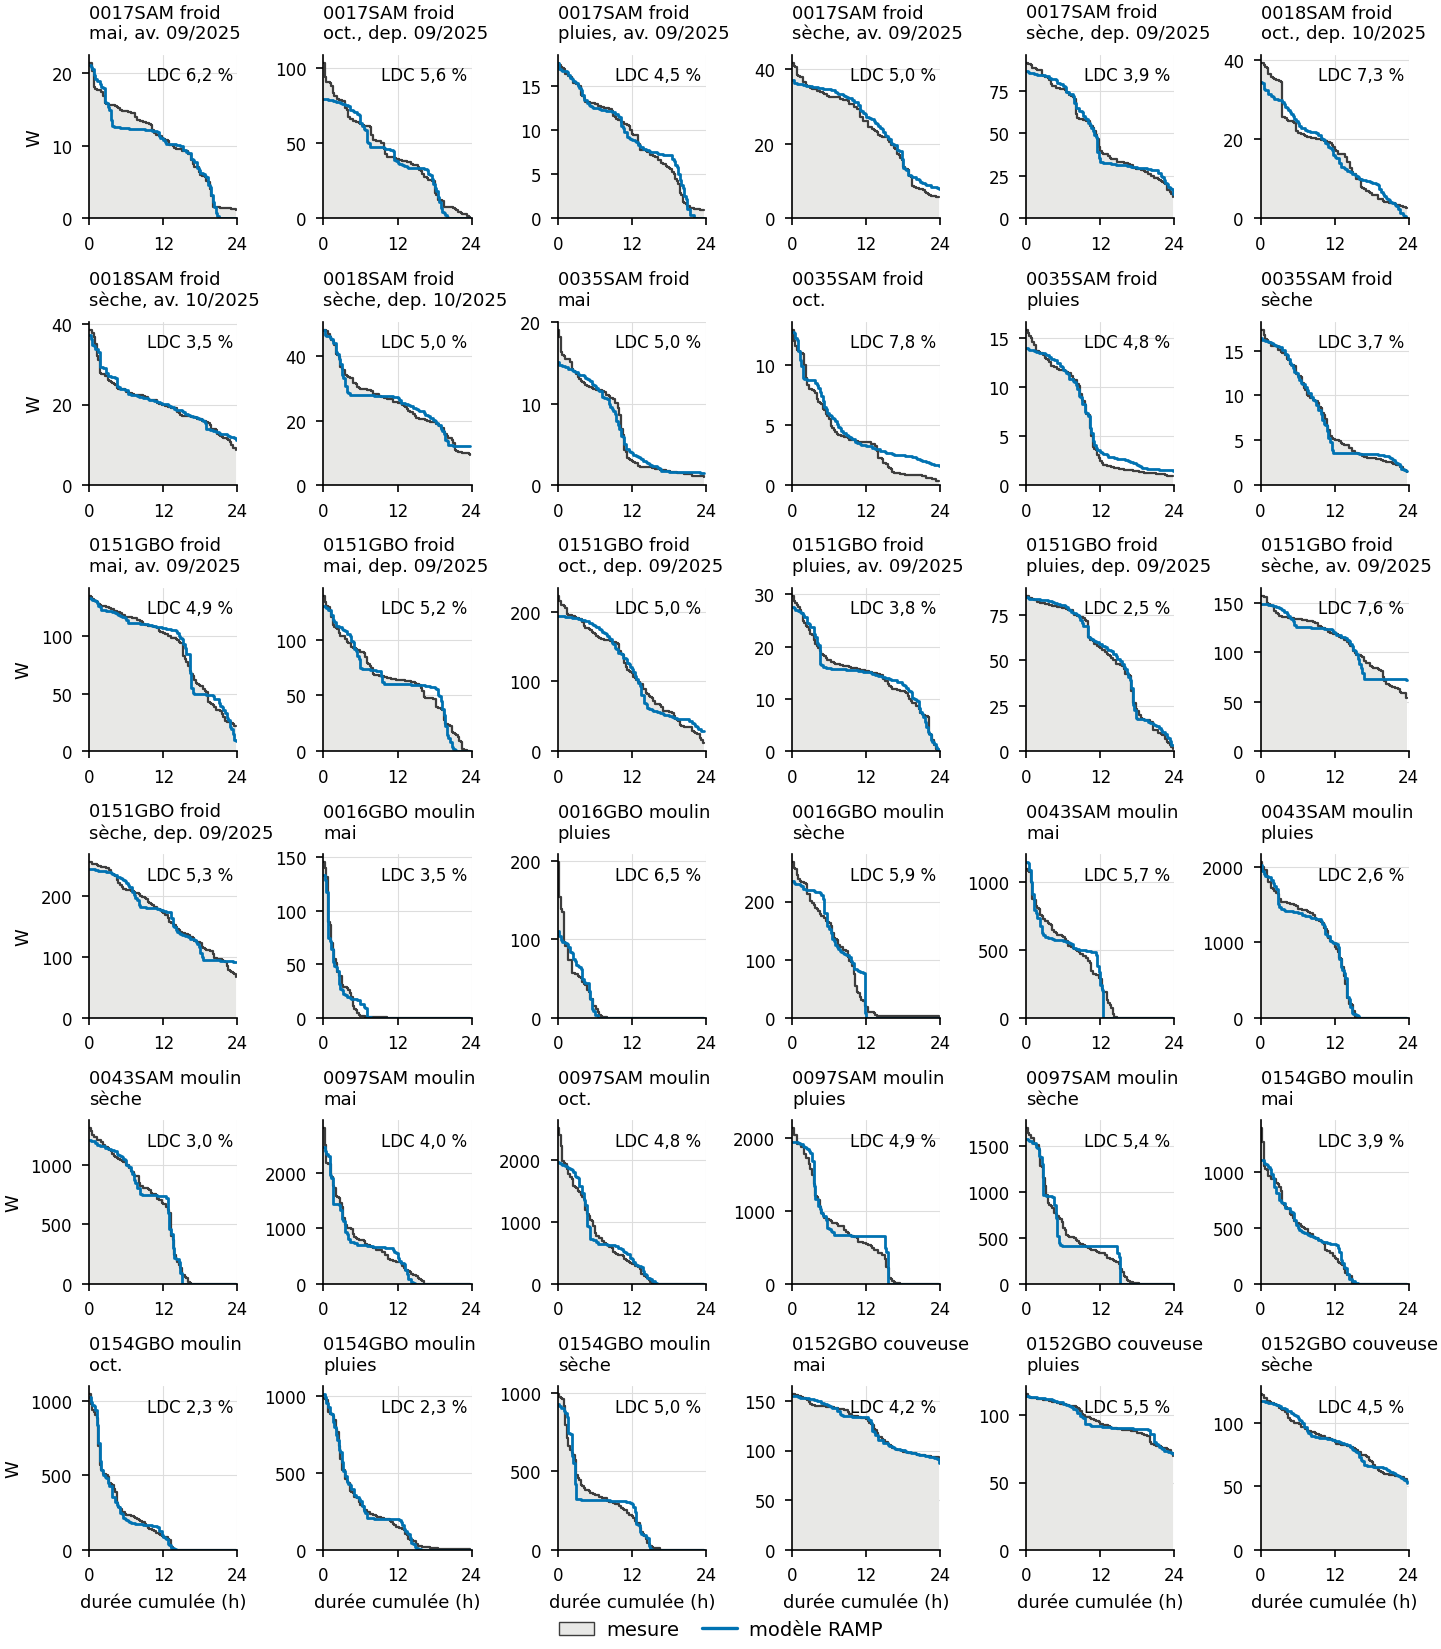

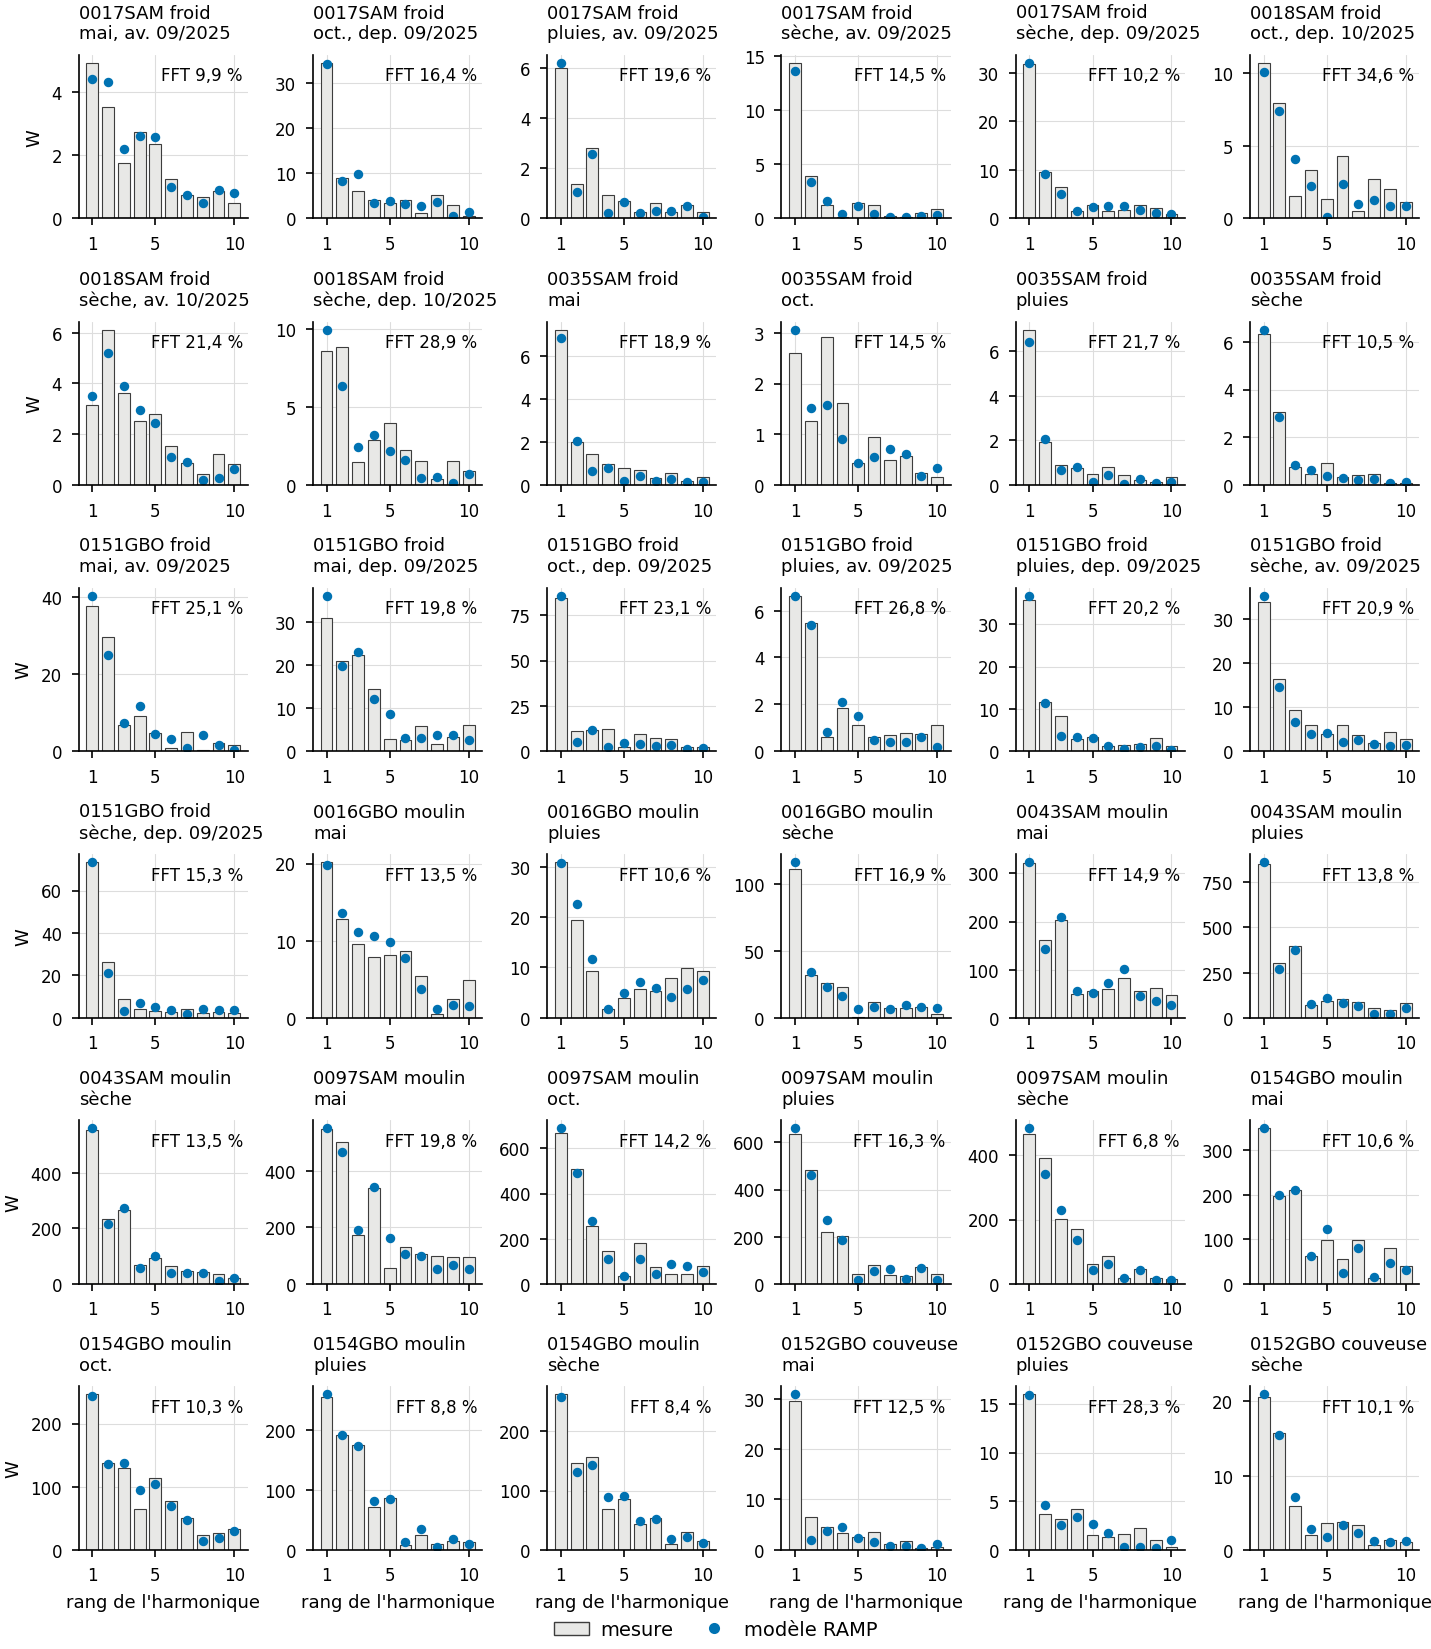

In [2]:
display(Image(CURVES / "ldc_saison.png", width=900))
display(Image(CURVES / "fft_saison.png", width=900))

## Monthly targets, client by client

Change `CLIENT` to see another appliance (0016GBO, 0017SAM, 0018SAM, 0035SAM, 0043SAM, 0097SAM,
0151GBO, 0152GBO, 0154GBO).

### 0035SAM

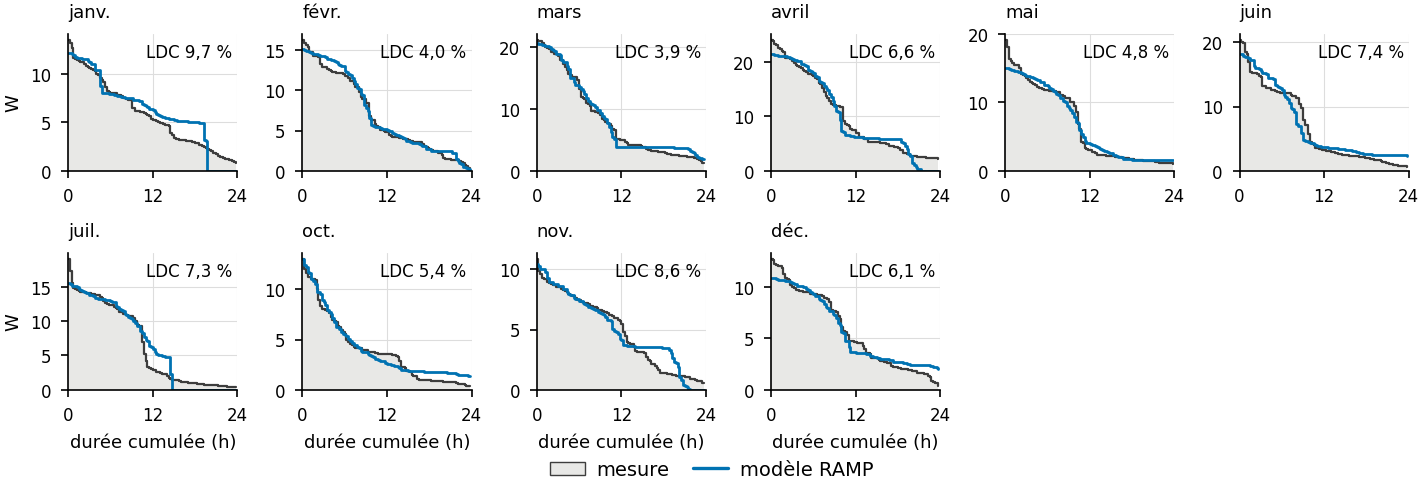

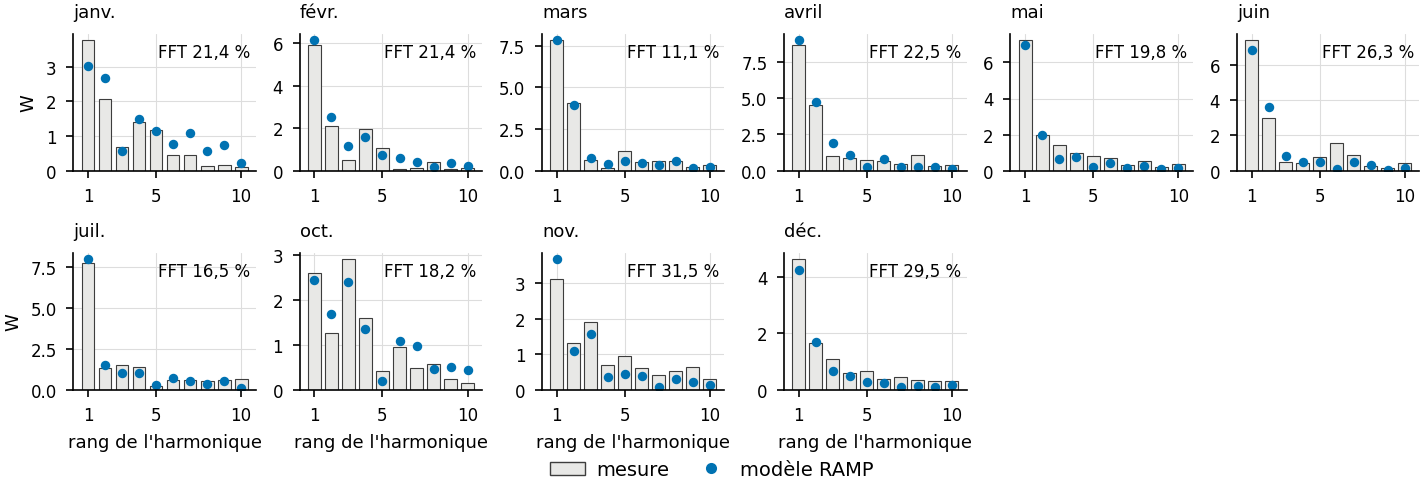

In [3]:
CLIENT = "0035SAM"

display(Markdown(f"### {CLIENT}"))
display(Image(CURVES / f"ldc_mois_{CLIENT}.png", width=900))
display(Image(CURVES / f"fft_mois_{CLIENT}.png", width=900))

To draw the figures again from the committed results:

```
cd src
python step10_ldc_fft.py
```